In [ ]:
import zipfile
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

In [ ]:
!pip install gdown
import gdown

In [ ]:
file_id = "1KEwL97mJH-B1VTXAK4_WAOkE4kfCQlEB"
gdown.download(f"https://drive.google.com/uc?id={file_id}", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1KEwL97mJH-B1VTXAK4_WAOkE4kfCQlEB
From (redirected): https://drive.google.com/uc?id=1KEwL97mJH-B1VTXAK4_WAOkE4kfCQlEB&confirm=t&uuid=0fc1dc85-0d66-425d-b3a7-feb24dfb2122
To: /content/Copy of waterPuddle.zip
100%|██████████| 825M/825M [00:09<00:00, 91.4MB/s]


'Copy of waterPuddle.zip'

In [ ]:
zip_path = "/content/Copy of waterPuddle.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Check contents
os.listdir(extract_path)

['.config',
 'Copy of waterPuddle.zip',
 'test',
 'waterPuddle',
 'best_unet_model.pth',
 'train',
 'sample_data']

In [ ]:
import os

# Adjust path if needed
data_dir = "/content/waterPuddle"
for root, dirs, files in os.walk(data_dir):
    print(f"\n📂 Directory: {root}")
    for file in files[:5]:  # show up to 5 files per folder
        print("   └──", file)


📂 Directory: /content/waterPuddle

📂 Directory: /content/waterPuddle/annotations

📂 Directory: /content/waterPuddle/annotations/4
   └── 35056_0.png
   └── 6099_0.png
   └── 4086_0.png
   └── 57077_0.png
   └── 440106_0.png

📂 Directory: /content/waterPuddle/annotations/1
   └── 1042_0.png
   └── 140100_0.png
   └── 11080_0.png
   └── 10102_3.png
   └── 13093_0.png

📂 Directory: /content/waterPuddle/annotations/7
   └── img-000004208_2.png
   └── img-000004409_1.png
   └── img-000004741_0.png
   └── img-000003891_1.png
   └── mumbai-1644405555381_0.png

📂 Directory: /content/waterPuddle/annotations/2
   └── 17034_1.png
   └── 1568013777-pothole_4.png
   └── 1568136800-Potholes-Mumbai_22.png
   └── 19026_1.png
   └── 16081_2.png

📂 Directory: /content/waterPuddle/annotations/3
   └── 23034_1.png
   └── 2505_0.png
   └── 2505_9.png
   └── 2205_4.png
   └── 29056_0.png

📂 Directory: /content/waterPuddle/annotations/6
   └── img-000001013_2.png
   └── img-000000912_1.png
   └── img-000002

In [ ]:
!pip install opencv-python


In [ ]:
import cv2
import matplotlib.pyplot as plt

def load_image_and_annotation(class_id, img_name=None):
    img_dir = f"/content/waterPuddle/imgs/{class_id}"
    ann_dir = f"/content/waterPuddle/annotations/{class_id}"

    # List files
    img_files = sorted(os.listdir(img_dir))
    ann_files = sorted(os.listdir(ann_dir))

    # Pick a specific file or the first one
    if img_name is None:
        img_name = img_files[0]

    # Try to find corresponding annotation
    base_name = os.path.splitext(img_name)[0]
    ann_match = [f for f in ann_files if base_name in f]

    if not ann_match:
        print(f"No annotation found for {img_name}")
        return

    img_path = os.path.join(img_dir, img_name)
    ann_path = os.path.join(ann_dir, ann_match[0])

    # Load
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(ann_path, cv2.IMREAD_GRAYSCALE)

    # Plot
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title(f"Image: {img_name}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Annotation: {ann_match[0]}")
    plt.axis("off")
    plt.show()


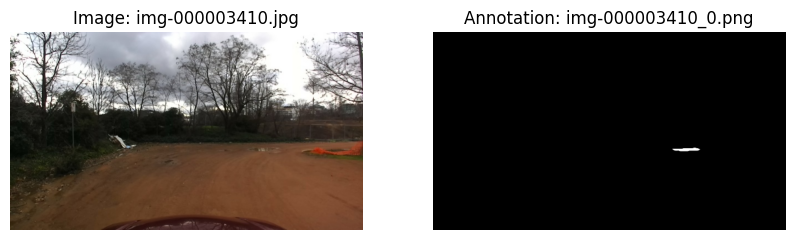

In [ ]:
load_image_and_annotation(class_id="7")

In [ ]:
import os

imgs_dir = "/content/waterPuddle/imgs"
annotations_dir = "/content/waterPuddle/annotations"

print(f"{'Class':<6} | {'Images':<6} | {'Annotations':<11}")
print("-" * 32)

for class_id in sorted(os.listdir(imgs_dir)):
    class_img_path = os.path.join(imgs_dir, class_id)
    class_ann_path = os.path.join(annotations_dir, class_id)

    if not os.path.isdir(class_img_path):
        continue

    num_imgs = len([f for f in os.listdir(class_img_path) if f.endswith(('.jpg', '.png'))])
    num_anns = len([f for f in os.listdir(class_ann_path) if f.endswith('.png')]) if os.path.exists(class_ann_path) else 0

    print(f"{class_id:<6} | {num_imgs:<6} | {num_anns:<11}")


Class  | Images | Annotations
--------------------------------
1      | 500    | 793        
2      | 500    | 959        
3      | 500    | 796        
4      | 500    | 287        
5      | 499    | 1813       
6      | 486    | 1378       
7      | 469    | 1203       


In [ ]:
!ls train/annotations/ | wc -l

2750


In [ ]:
extracted_path = "/content/"
train_path = "/content/train"
test_path = "/content/test"

In [ ]:
os.makedirs(train_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)
os.makedirs(os.path.join(train_path,"imgs"), exist_ok=True)
os.makedirs(os.path.join(train_path,"annotations"),  exist_ok=True)
os.makedirs(os.path.join(test_path,"imgs"),  exist_ok=True)
os.makedirs(os.path.join(test_path,"annotations"),  exist_ok=True)

In [ ]:
import os
import random
import shutil
import cv2 as cv

# List all subdirectories in 'imgs' directory
img_subfolders = [f for f in os.listdir(os.path.join(extracted_path, 'waterPuddle/imgs')) if os.path.isdir(os.path.join(extracted_path, 'waterPuddle/imgs', f))]

# Iterate over each subfolder
for subfolder in img_subfolders:
    subfolder_path = os.path.join(extracted_path, 'waterPuddle/imgs', subfolder)
    print("subfolder_path",subfolder_path)
    # List all image files in the current subfolder
    imgs_files = [f for f in os.listdir(subfolder_path) if (f.endswith('.jpg') or f.endswith('.png'))]
    # Shuffle the files for randomness before splitting
    random.shuffle(imgs_files)
    print('all images',len(imgs_files))
    # Split the data
    split_index = int(0.8 * len(imgs_files))
    train_imgs = imgs_files[:split_index]
    test_imgs = imgs_files[split_index:]
    print('train_imgs',len(train_imgs))
    print('test_imgs',len(test_imgs))

    # Merge masks and move files to train folder
    for img in train_imgs:
      if img.endswith('.jpg'):
        annotation_file = os.path.join(extracted_path, 'waterPuddle/annotations', subfolder, img.replace('.jpg', '_0.png'))
      elif img.endswith('.png'):
        annotation_file = os.path.join(extracted_path, 'waterPuddle/annotations', subfolder, img.replace('.png', '_0.png'))
      i = 0 #index of annotation
      # Check if the annotation file exist
      print('img',img)
      label_path = annotation_file
      print('annotation_file',annotation_file)

      while os.path.exists(label_path):
        print('label_path',label_path)

        label_path = "%s_%d.png" % (annotation_file.rsplit("_0")[0],i+1)
        if i == 0 and os.path.exists(label_path):
          print('first mask')
          mask = cv.imread(annotation_file,1)
          i = i +1
        elif i != 0 and os.path.exists(label_path) :
          print(f'{i}th mask')
          label = cv.imread(label_path,1)
          mask = cv.bitwise_or(label, mask)
          i = i +1
        elif i== 0 and not os.path.exists(label_path):
          print('only one mask')
          mask = cv.imread(annotation_file,1)
          img_path = os.path.join(train_path, 'imgs', img)
          shutil.move(os.path.join(subfolder_path, img), img_path)
          img = img.rsplit('.')[0]
          print('img',img)
          annotations_path = os.path.join(train_path, 'annotations', img+'.png')
          print("img_path",img_path)
          print("annotations_path",annotations_path)
          cv.imwrite(annotations_path,mask)
          print('saved-train')

        elif i!=0 and not os.path.exists(label_path) :
          img_path = os.path.join(train_path, 'imgs', img)
          shutil.move(os.path.join(subfolder_path, img), img_path)
          img = img.rsplit('.')[0]
          print('img',img)
          annotations_path = os.path.join(train_path, 'annotations', img+'.png')
          print("img_path",img_path)
          print("annotations_path",annotations_path)
          cv.imwrite(annotations_path,mask)
          print('saved-train')


    # Merge masks and move files to train folder
    for img in test_imgs:
      if img.endswith('.jpg'):
        annotation_file = os.path.join(extracted_path, 'waterPuddle/annotations', subfolder, img.replace('.jpg', '_0.png'))
      elif img.endswith('.png'):
        annotation_file = os.path.join(extracted_path, 'waterPuddle/annotations', subfolder, img.replace('.png', '_0.png'))
      i = 0 #index of annotation
      # Check if the annotation file exist
      print('img',img)
      label_path = annotation_file
      print('annotation_file',annotation_file)

      while os.path.exists(label_path):
        print('label_path',label_path)

        label_path = "%s_%d.png" % (annotation_file.rsplit("_0")[0],i+1)
        if i == 0 and os.path.exists(label_path):
          print('first mask')
          mask = cv.imread(annotation_file,1)
          i = i +1
        elif i != 0 and os.path.exists(label_path) :
          print(f'{i}th mask')
          label = cv.imread(label_path,1)
          mask = cv.bitwise_or(label, mask)
          i = i +1
        elif i== 0 and not os.path.exists(label_path):
          print('only one mask')
          mask = cv.imread(annotation_file,1)
          img_path = os.path.join(test_path, 'imgs', img)
          shutil.move(os.path.join(subfolder_path, img), img_path)
          img = img.rsplit('.')[0]
          print('img',img)
          annotations_path = os.path.join(test_path, 'annotations', img+'.png')
          print("img_path",img_path)
          print("annotations_path",annotations_path)
          cv.imwrite(annotations_path,mask)
          print('saved-test')

        elif i!=0 and not os.path.exists(label_path) :
          img_path = os.path.join(test_path, 'imgs', img)
          shutil.move(os.path.join(subfolder_path, img), img_path)
          img = img.rsplit('.')[0]
          print('img',img)
          annotations_path = os.path.join(test_path, 'annotations', img+'.png')
          print("img_path",img_path)
          print("annotations_path",annotations_path)
          cv.imwrite(annotations_path,mask)
          print('saved-test')

Streaming output truncated to the last 5000 lines.
6th mask
label_path /content/waterPuddle/annotations/5/img-000000291_7.png
7th mask
label_path /content/waterPuddle/annotations/5/img-000000291_8.png
8th mask
label_path /content/waterPuddle/annotations/5/img-000000291_9.png
9th mask
label_path /content/waterPuddle/annotations/5/img-000000291_10.png
img img-000000291
img_path /content/train/imgs/img-000000291.png
annotations_path /content/train/annotations/img-000000291.png
saved-train
img Mumbai-Potholes.jpg
annotation_file /content/waterPuddle/annotations/5/Mumbai-Potholes_0.png
label_path /content/waterPuddle/annotations/5/Mumbai-Potholes_0.png
first mask
label_path /content/waterPuddle/annotations/5/Mumbai-Potholes_1.png
img Mumbai-Potholes
img_path /content/train/imgs/Mumbai-Potholes.jpg
annotations_path /content/train/annotations/Mumbai-Potholes.png
saved-train
img 80104.jpg
annotation_file /content/waterPuddle/annotations/5/80104_0.png
label_path /content/waterPuddle/annotations

In [ ]:
img_height, img_width = 128, 128
batch_size = 32
num_epochs = 30

class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, mask_transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.mask_transform = mask_transform

        self.images = sorted([f for f in os.listdir(image_dir)
                            if f.endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))])

        # Verify that masks exist for all images
        self.valid_images = []
        for img in self.images:
            # Check if corresponding mask exists (might have different extension)
            base_name = os.path.splitext(img)[0]
            mask_exists = any(os.path.exists(os.path.join(mask_dir, base_name + ext))
                            for ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tiff'])
            if mask_exists:
                self.valid_images.append(img)
            else:
                print(f"Warning: No mask found for image {img}")

        self.images = self.valid_images
        print(f"Found {len(self.images)} valid image-mask pairs")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        # Load mask - try different extensions
        base_name = os.path.splitext(img_name)[0]
        mask = None
        for ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']:
            mask_path = os.path.join(self.mask_dir, base_name + ext)
            if os.path.exists(mask_path):
                mask = Image.open(mask_path).convert('L')  # Convert to grayscale
                break

        if mask is None:
            raise FileNotFoundError(f"Mask not found for {img_name}")

        # Apply transforms
        if self.transform:
            image = self.transform(image)
        if self.mask_transform:
            mask = self.mask_transform(mask)

        return image, mask

image_transform = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),  # Converts PIL to tensor and scales to [0, 1]
])

mask_transform = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
])

print("Loading training dataset...")
train_dataset = SegmentationDataset(
    image_dir=os.path.join(train_path, 'imgs'),
    mask_dir=os.path.join(train_path, 'annotations'),
    transform=image_transform,
    mask_transform=mask_transform
)

print("\nLoading test dataset...")
test_dataset = SegmentationDataset(
    image_dir=os.path.join(test_path, 'imgs'),
    mask_dir=os.path.join(test_path, 'annotations'),
    transform=image_transform,
    mask_transform=mask_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  # Shuffle training data
    num_workers=8,  # Parallel data loading
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=False  # Don't drop the last incomplete batch
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,  # Don't shuffle test data
    num_workers=8,
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=False
)

print(f"\nTraining batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

if len(train_loader) > 0:
    images, masks = next(iter(train_loader))
    print(f"\nSample batch shape:")
    print(f"Images: {images.shape} (dtype: {images.dtype}, range: [{images.min():.3f}, {images.max():.3f}])")
    print(f"Masks: {masks.shape} (dtype: {masks.dtype}, range: [{masks.min():.3f}, {masks.max():.3f}])")

Loading training dataset...
Found 2851 valid image-mask pairs

Loading test dataset...
Found 1409 valid image-mask pairs

Training batches: 90
Test batches: 45

Sample batch shape:
Images: torch.Size([32, 3, 128, 128]) (dtype: torch.float32, range: [0.000, 1.000])
Masks: torch.Size([32, 1, 128, 128]) (dtype: torch.float32, range: [0.000, 1.000])


In [ ]:
import torch
import torch.nn.functional as F

def iou(y_true, y_pred, smooth=100):
    """
    Calculate IoU using the same formula as Keras implementation.
    Note: This uses squared values in denominator which is non-standard for IoU.
    """
    # Ensure float tensors
    y_true = y_true.float()
    y_pred = y_pred.float()

    # Calculate intersection
    intersection = torch.sum(torch.abs(y_true * y_pred), dim=-1)

    # Calculate sum of squares
    sum_ = torch.sum(torch.square(y_true), dim=-1) + torch.sum(torch.square(y_pred), dim=-1)

    # Calculate IoU
    jac = (intersection + smooth) / (sum_ - intersection + smooth)

    return jac

def dice_coef(y_true, y_pred, smooth=100):
    """
    Calculate Dice coefficient exactly as in Keras implementation.
    """
    # Flatten the tensors
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()

    # Calculate intersection
    intersection = torch.sum(y_true_f * y_pred_f)

    # Calculate Dice coefficient
    return (2. * intersection + smooth) / (torch.sum(y_true_f) + torch.sum(y_pred_f) + smooth)

def precision(y_true, y_pred):
    """
    Calculate precision exactly as in Keras implementation.
    """
    # Clip values between 0 and 1, then round
    true_positives = torch.sum(torch.round(torch.clamp(y_true * y_pred, 0, 1)))
    predicted_positives = torch.sum(torch.round(torch.clamp(y_pred, 0, 1)))

    # Calculate precision with epsilon to avoid division by zero
    precision_value = true_positives / (predicted_positives + 1e-7)

    return precision_value

def recall(y_true, y_pred):
    """
    Calculate recall exactly as in Keras implementation.
    """
    # Clip values between 0 and 1, then round
    true_positives = torch.sum(torch.round(torch.clamp(y_true * y_pred, 0, 1)))
    possible_positives = torch.sum(torch.round(torch.clamp(y_true, 0, 1)))

    # Calculate recall with epsilon to avoid division by zero
    recall_value = true_positives / (possible_positives + 1e-7)

    return recall_value

def accuracy(y_true, y_pred):
    """
    Calculate accuracy exactly as in Keras implementation.
    """
    # Round predictions and compare with true values
    return torch.mean((y_true == torch.round(y_pred)).float())

def jaccard_distance(y_true, y_pred, smooth=100):
    """
    Calculate Jaccard distance (1 - IoU) exactly as in Keras implementation.
    """
    # Cast to float32
    y_true = y_true.float()
    y_pred = y_pred.float()

    # Calculate intersection
    intersection = torch.sum(torch.abs(y_true * y_pred), dim=-1)

    # Calculate sum of squares
    sum_ = torch.sum(torch.square(y_true), dim=-1) + torch.sum(torch.square(y_pred), dim=-1)

    # Calculate Jaccard index
    jac = (intersection + smooth) / (sum_ - intersection + smooth)

    # Return Jaccard distance
    return 1 - jac

#UNet

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

# Your U-Net model (same as before)
class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1, bilinear=False):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return torch.sigmoid(logits)


modelName = "UNet"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize UNet model
model = UNet(n_channels=3, n_classes=1, bilinear=False).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters")

# Function to calculate all metrics
def calculate_all_metrics(y_true, y_pred):
    """Calculate all metrics for a batch"""
    metrics = {}

    # Convert to binary predictions
    y_pred_binary = (y_pred > 0.5).float()

    # Calculate each metric
    metrics['iou'] = iou(y_true, y_pred_binary).mean().item()
    metrics['dice'] = dice_coef(y_true, y_pred_binary).item()
    metrics['precision'] = precision(y_true, y_pred_binary).item()
    metrics['recall'] = recall(y_true, y_pred_binary).item()
    metrics['accuracy'] = accuracy(y_true, y_pred_binary).item()
    metrics['jaccard_distance'] = jaccard_distance(y_true, y_pred_binary).mean().item()

    return metrics

def validate_model():
    """Comprehensive validation with all metrics"""
    model.eval()

    # Initialize metric accumulators
    total_metrics = {
        'iou': 0,
        'dice': 0,
        'precision': 0,
        'recall': 0,
        'accuracy': 0,
        'jaccard_distance': 0,
        'loss': 0
    }

    num_batches = 0

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, masks)
            total_metrics['loss'] += loss.item()

            # Calculate all metrics
            batch_metrics = calculate_all_metrics(masks, outputs)

            # Accumulate metrics
            for key, value in batch_metrics.items():
                total_metrics[key] += value

            num_batches += 1

    # Calculate averages
    avg_metrics = {key: value / num_batches for key, value in total_metrics.items()}

    # Print results
    print("\n" + "="*50)
    print("VALIDATION RESULTS:")
    print("="*50)
    print(f"Loss:              {avg_metrics['loss']:.4f}")
    print(f"IoU:               {avg_metrics['iou']:.4f}")
    print(f"Dice Coefficient:  {avg_metrics['dice']:.4f}")
    print(f"Precision:         {avg_metrics['precision']:.4f}")
    print(f"Recall:            {avg_metrics['recall']:.4f}")
    print(f"Accuracy:          {avg_metrics['accuracy']:.4f}")
    print(f"Jaccard Distance:  {avg_metrics['jaccard_distance']:.4f}")
    print("="*50 + "\n")

    model.train()
    return avg_metrics

def train_model():
    """Training loop with comprehensive metric tracking"""
    best_dice = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        epoch_metrics = {
            'iou': 0,
            'dice': 0,
            'precision': 0,
            'recall': 0,
            'accuracy': 0,
            'jaccard_distance': 0
        }

        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 30)

        for batch_idx, (images, masks) in enumerate(train_loader):
            images = images.to(device)
            masks = masks.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Calculate metrics for this batch
            with torch.no_grad():
                batch_metrics = calculate_all_metrics(masks, outputs)
                for key, value in batch_metrics.items():
                    epoch_metrics[key] += value

            # Print progress every 20 batches
            if batch_idx % 20 == 0:
                print(f'Batch {batch_idx:3d}/{len(train_loader)} | Loss: {loss.item():.4f} | '
                      f'IoU: {batch_metrics["iou"]:.3f} | Dice: {batch_metrics["dice"]:.3f}')

        # Calculate epoch averages
        avg_loss = running_loss / len(train_loader)
        avg_epoch_metrics = {key: value / len(train_loader) for key, value in epoch_metrics.items()}

        print(f'\nEpoch {epoch+1} Training Results:')
        print(f'Average Loss: {avg_loss:.4f}')
        print(f'Average IoU: {avg_epoch_metrics["iou"]:.4f}')
        print(f'Average Dice: {avg_epoch_metrics["dice"]:.4f}')
        print(f'Average Precision: {avg_epoch_metrics["precision"]:.4f}')
        print(f'Average Recall: {avg_epoch_metrics["recall"]:.4f}')
        print(f'Average Accuracy: {avg_epoch_metrics["accuracy"]:.4f}')

        # Validation every 2 epochs
        if epoch % 2 == 0 or epoch == num_epochs - 1:
            val_metrics = validate_model()

            # Save best model based on Dice score
            if val_metrics['dice'] > best_dice:
                best_dice = val_metrics['dice']
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'dice_score': best_dice,
                    'all_metrics': val_metrics
                }, 'best_model.pth')
                print(f"✓ New best model saved with Dice score: {best_dice:.4f}")

import json
import os

def save_metrics(model_name, metrics, file_path="model_metrics.json"):
    """Save evaluation metrics to a JSON file."""
    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            all_metrics = json.load(f)
    else:
        all_metrics = {}

    all_metrics[model_name] = metrics

    with open(file_path, 'w') as f:
        json.dump(all_metrics, f, indent=4)

    print(f"✓ Metrics for {model_name} saved to {file_path}")


def evaluate_final_model():
    """Final comprehensive evaluation"""
    print("\n" + "="*60)
    print("FINAL MODEL EVALUATION")
    print("="*60)

    # Load best model if it exists
    try:
        checkpoint = torch.load('best_model.pth')
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded best model from epoch {checkpoint['epoch']} with Dice: {checkpoint['dice_score']:.4f}")
    except:
        print("Using current model weights for evaluation")

    # Run final validation
    final_metrics = validate_model()
    save_metrics(modelName, final_metrics)

    return final_metrics

def load_metrics(file_path="model_metrics.json"):
    with open(file_path, 'r') as f:
        return json.load(f)


# Start training
if __name__ == "__main__":
    print("Starting training with comprehensive metrics...")
    train_model()

    # Final evaluation
    final_results = evaluate_final_model()

    print("\nTraining completed!")
    print(f"Final Results Summary:")
    for metric, value in final_results.items():
        print(f"{metric.capitalize()}: {value:.4f}")

    metrics_dict = load_metrics()
    print(metrics_dict)


Model has 29,443,585 trainable parameters
Starting training with comprehensive metrics...

Epoch 1/30
------------------------------
Batch   0/90 | Loss: 0.6555 | IoU: 0.705 | Dice: 0.141
Batch  20/90 | Loss: 0.4755 | IoU: 0.891 | Dice: 0.240
Batch  40/90 | Loss: 0.3506 | IoU: 0.937 | Dice: 0.534
Batch  60/90 | Loss: 0.2838 | IoU: 0.946 | Dice: 0.555
Batch  80/90 | Loss: 0.2690 | IoU: 0.939 | Dice: 0.435

Epoch 1 Training Results:
Average Loss: 0.3724
Average IoU: 0.9115
Average Dice: 0.3997
Average Precision: 0.4570
Average Recall: 0.3839
Average Accuracy: 0.8770

VALIDATION RESULTS:
Loss:              0.2455
IoU:               0.9397
Dice Coefficient:  0.4309
Precision:         0.4735
Recall:            0.4096
Accuracy:          0.9082
Jaccard Distance:  0.0603

✓ New best model saved with Dice score: 0.4309

Epoch 2/30
------------------------------
Batch   0/90 | Loss: 0.2519 | IoU: 0.937 | Dice: 0.547
Batch  20/90 | Loss: 0.1905 | IoU: 0.959 | Dice: 0.479
Batch  40/90 | Loss: 0.16

KeyboardInterrupt: 

In [ ]:
import torch
import json
import os
from datetime import datetime

def test_model(model, test_loader, device, model_path=None, save_results=True):
    """Comprehensive testing with all metrics and detailed analysis"""

    # Load model if path provided
    if model_path and os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✓ Loaded model from {model_path}")
        if 'epoch' in checkpoint:
            print(f"  Model was saved at epoch {checkpoint['epoch']}")
        if 'dice_score' in checkpoint:
            print(f"  Training Dice score: {checkpoint['dice_score']:.4f}")
    else:
        print("Using current model weights for testing")

    model.eval()

    # Initialize metric accumulators
    total_metrics = {
        'iou': 0,
        'dice': 0,
        'precision': 0,
        'recall': 0,
        'accuracy': 0,
        'jaccard_distance': 0,
        'loss': 0
    }

    # For per-batch analysis
    batch_metrics = []
    num_batches = 0
    total_samples = 0

    # Loss function for testing
    criterion = torch.nn.BCELoss()

    print("\n" + "="*60)
    print("RUNNING COMPREHENSIVE TEST EVALUATION")
    print("="*60)

    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(test_loader):
            images = images.to(device)
            masks = masks.to(device)
            batch_size = images.size(0)
            total_samples += batch_size

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, masks)
            total_metrics['loss'] += loss.item()

            # Calculate all metrics for this batch
            batch_metric_values = calculate_all_metrics(masks, outputs)
            batch_metric_values['loss'] = loss.item()
            batch_metric_values['batch_size'] = batch_size
            batch_metrics.append(batch_metric_values)

            # Accumulate metrics
            for key, value in batch_metric_values.items():
                if key not in ['batch_size']:
                    total_metrics[key] += value

            num_batches += 1

            # Print progress every 5 batches
            if batch_idx % 5 == 0:
                print(f"Processed batch {batch_idx+1}/{len(test_loader)} "
                      f"({total_samples} samples) | "
                      f"IoU: {batch_metric_values['iou']:.3f} | "
                      f"Dice: {batch_metric_values['dice']:.3f}")

    # Calculate final averages
    avg_metrics = {key: value / num_batches for key, value in total_metrics.items()}

    # Calculate standard deviations
    std_metrics = {}
    for metric in ['iou', 'dice', 'precision', 'recall', 'accuracy', 'jaccard_distance', 'loss']:
        values = [batch[metric] for batch in batch_metrics]
        mean_val = sum(values) / len(values)
        variance = sum((x - mean_val) ** 2 for x in values) / len(values)
        std_metrics[metric] = variance ** 0.5

    # Print comprehensive test results
    print("\n" + "="*60)
    print("FINAL TEST RESULTS")
    print("="*60)
    print(f"Total test samples: {total_samples}")
    print(f"Total test batches: {num_batches}")
    print("-" * 60)
    print(f"{'Metric':<20} {'Mean':<10} {'Std':<10} {'Range'}")
    print("-" * 60)

    for metric in ['loss', 'iou', 'dice', 'precision', 'recall', 'accuracy', 'jaccard_distance']:
        values = [batch[metric] for batch in batch_metrics]
        min_val = min(values)
        max_val = max(values)
        print(f"{metric.capitalize():<20} {avg_metrics[metric]:<10.4f} {std_metrics[metric]:<10.4f} [{min_val:.3f}, {max_val:.3f}]")

    print("=" * 60)

    # Additional analysis
    print("\nDETAILED ANALYSIS:")
    print("-" * 30)

    # Best and worst performing batches
    dice_values = [batch['dice'] for batch in batch_metrics]
    best_batch_idx = dice_values.index(max(dice_values))
    worst_batch_idx = dice_values.index(min(dice_values))

    print(f"Best performing batch:  #{best_batch_idx+1} (Dice: {max(dice_values):.4f})")
    print(f"Worst performing batch: #{worst_batch_idx+1} (Dice: {min(dice_values):.4f})")

    # Performance distribution
    excellent = sum(1 for d in dice_values if d > 0.8)
    good = sum(1 for d in dice_values if 0.6 < d <= 0.8)
    fair = sum(1 for d in dice_values if 0.4 < d <= 0.6)
    poor = sum(1 for d in dice_values if d <= 0.4)

    print(f"\nPerformance distribution (by Dice score):")
    print(f"  Excellent (>0.8):     {excellent:3d} batches ({excellent/num_batches*100:.1f}%)")
    print(f"  Good (0.6-0.8):       {good:3d} batches ({good/num_batches*100:.1f}%)")
    print(f"  Fair (0.4-0.6):       {fair:3d} batches ({fair/num_batches*100:.1f}%)")
    print(f"  Poor (≤0.4):          {poor:3d} batches ({poor/num_batches*100:.1f}%)")

    # Save results if requested
    if save_results:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        results = {
            'timestamp': timestamp,
            'model_path': model_path,
            'total_samples': total_samples,
            'total_batches': num_batches,
            'average_metrics': avg_metrics,
            'std_metrics': std_metrics,
            'batch_metrics': batch_metrics,
            'performance_distribution': {
                'excellent': excellent,
                'good': good,
                'fair': fair,
                'poor': poor
            }
        }

        results_file = f'test_results_{timestamp}.json'
        with open(results_file, 'w') as f:
            json.dump(results, f, indent=2)
        print(f"\n✓ Test results saved to {results_file}")

    return avg_metrics, batch_metrics

def calculate_all_metrics(y_true, y_pred):
    """Calculate all metrics for a batch"""
    metrics = {}

    # Convert to binary predictions
    y_pred_binary = (y_pred > 0.5).float()

    # Calculate each metric using your defined functions
    metrics['iou'] = iou(y_true, y_pred_binary).mean().item()
    metrics['dice'] = dice_coef(y_true, y_pred_binary).item()
    metrics['precision'] = precision(y_true, y_pred_binary).item()
    metrics['recall'] = recall(y_true, y_pred_binary).item()
    metrics['accuracy'] = accuracy(y_true, y_pred_binary).item()
    metrics['jaccard_distance'] = jaccard_distance(y_true, y_pred_binary).mean().item()

    return metrics

# Simple test function without detailed analysis
def quick_test(model, test_loader, device):
    """Quick test with just average metrics"""
    model.eval()
    total_metrics = {
        'iou': 0, 'dice': 0, 'precision': 0,
        'recall': 0, 'accuracy': 0, 'jaccard_distance': 0
    }

    num_batches = 0
    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)

            batch_metrics = calculate_all_metrics(masks, outputs)
            for key, value in batch_metrics.items():
                total_metrics[key] += value
            num_batches += 1

    # Calculate averages
    avg_metrics = {key: value / num_batches for key, value in total_metrics.items()}

    print("Quick Test Results:")
    for metric, value in avg_metrics.items():
        print(f"{metric.capitalize()}: {value:.4f}")

    return avg_metrics

# Usage examples:
if __name__ == "__main__":
    # Assuming you have model, test_loader, and device defined

    # Method 1: Comprehensive test with saved model
    test_metrics, batch_results = test_model(
        model=model,
        test_loader=test_loader,
        device=device,
        model_path='best_model.pth',  # Path to your saved model
        save_results=True
    )

    # Method 2: Test current model without saving
    # test_metrics, batch_results = test_model(
    #     model=model,
    #     test_loader=test_loader,
    #     device=device,
    #     model_path=None,
    #     save_results=False
    # )

    # Method 3: Quick test (just averages)
    # quick_metrics = quick_test(model, test_loader, device)